<a href="https://colab.research.google.com/github/aadityane93/Deep_Learning/blob/main/Topic_2_chapter7_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7 — Working with Keras: A Deep Dive
### Exercise Notebook

Fill in the blanks! Lines marked with `# TODO` or `# ???` need to be completed.
Commented-out lines show you what *should* be there — uncomment and complete them.

**Topics:**
1. Sequential API
2. Functional API (multi-input/multi-output)
3. Model subclassing
4. Built-in training loops
5. Custom metrics & callbacks
6. Custom training loops

---

## Setup

In [ ]:
!pip install keras keras-hub --upgrade -q

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
import numpy as np

---
## Exercise 1: The Sequential Model

**Task:** Build a Sequential model with two Dense layers using both construction styles.

In [ ]:
# --- Style A: pass all layers at construction time ---
# TODO: Create a keras.Sequential model with:
  # - Dense(64, activation="relu")
  # - Dense(10, activation="softmax")

model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [ ]:
model.build(input_shape=(None, 3))
model.summary(line_length=80)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                   │ (None, 64)               │           256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_10 (Dense)                  │ (None, 10)               │           650 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TODO: Re-create the model but add a keras.Input layer first,
#       so the summary is available before the final layer is added.

model = keras.Sequential()
model.add(keras.Input(shape=(3,)))
model.add(layers.Dense(64, activation="relu"))
model.summary(line_length=80)   # should already show 1 layer
model.add(layers.Dense(10, activation="softmax"))
model.summary(line_length=80)   # now shows both layers

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                  │ (None, 64)               │           256 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 256 (1.00 KB)

 Trainable params: 256 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                  │ (None, 64)               │           256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_12 (Dense)                  │ (None, 10)               │           650 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

---
## Exercise 2: The Functional API — Multi-input, Multi-output Model

**Task:** Build the customer-support ticket classifier from scratch.

In [ ]:
vocabulary_size  = 10000
num_tags         = 100
num_departments  = 4

In [ ]:
vocabulary_size  = 10000
num_tags         = 100
num_departments  = 4

# TODO: Define three keras.Input tensors — title, text_body, tags
# Hint: title and text_body have shape (vocabulary_size,), tags has shape (num_tags,)

title     = keras.Input(shape=(vocabulary_size,), name="title")
text_body = keras.Input(shape=(vocabulary_size,), name="text_body")
tags      = keras.Input(shape=(num_tags,), name="tags")

In [ ]:
# TODO: Concatenate the three inputs, then pass through a Dense(64, relu) layer
# Hint: use layers.Concatenate()([...])  then call the Dense layer on the result

features = layers.Concatenate()([title, text_body, tags])
features = layers.Dense(64, activation="relu", name="dense_features")(features)

In [ ]:
# TODO: Define two output heads from the shared features:
#   - priority:   Dense(1, sigmoid)                      → regression score
#   - department: Dense(num_departments, softmax)         → classification

priority   = layers.Dense(1, activation="sigmoid", name="priority")(features)
department = layers.Dense(num_departments, activation="softmax", name="department")(features)

In [ ]:

model = keras.Model(
    inputs=[title, text_body, tags],
    outputs=[priority, department],
)
model.summary(line_length=80)

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)    │ (None, 10000)     │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ text_body             │ (None, 10000)     │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ tags (InputLayer)     │ (None, 100)       │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ concatenate_2         │ (None, 20100)     │           0 │ title[0][0],       │
│ (Concatenate)         │                   │             │ text_body[0][0],   │
│                       │                   │             │ tags[0][0]         │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_features        │ (None, 64)        │   1,286,464 │ concatenate_2[0][… │
│ (Dense)               │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ priority (Dense)      │ (None, 1)         │          65 │ dense_features[0]… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ department (Dense)    │ (None, 4)         │         260 │ dense_features[0]… │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 1,286,789 (4.91 MB)

 Trainable params: 1,286,789 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

### 2b. Compile and train the multi-output model

In [ ]:
# Generate random dummy data
num_samples    = 1280
title_data     = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data      = np.random.randint(0, 2, size=(num_samples, num_tags))
priority_data  = np.random.random(size=(num_samples, 1))
department_data = np.random.randint(0, num_departments, size=(num_samples, 1))

In [ ]:
model.compile(
    optimizer="adam",
    loss={
        "priority":   "mean_squared_error",
        "department": "sparse_categorical_crossentropy",
    },
    metrics={
        "priority":   ["mean_absolute_error"],
        "department": ["accuracy"],
    },
)

In [ ]:
# TODO: fit the model for 1 epoch using dict-form inputs and outputs

model.fit(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    {"priority": priority_data, "department": department_data},
    epochs=1,
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - department_accuracy: 0.0000e+00 - department_loss: 4.1094 - loss: 4.2199 - priority_loss: 0.1105 - priority_mean_absolute_error: 1.2417


### 2c. Feature extraction — add a third output head

In [ ]:
# TODO: Access the output of the 'dense_features' layer (index 4)
#       and attach a new Dense(3, softmax) head called 'difficulty'.
#       Then create a new_model with 3 outputs.

features   = model.get_layer(name="dense_features").output
difficulty = layers.Dense(3, activation="softmax", name="difficulty")(features)

new_model = keras.Model(
    inputs=[title, text_body, tags],
    outputs=[priority, department, difficulty]
)
new_model.summary(line_length=80)

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)    │ (None, 10000)     │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ text_body             │ (None, 10000)     │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ tags (InputLayer)     │ (None, 100)       │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ concatenate_2         │ (None, 20100)     │           0 │ title[0][0],       │
│ (Concatenate)         │                   │             │ text_body[0][0],   │
│                       │                   │             │ tags[0][0]         │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_features        │ (None, 64)        │   1,286,464 │ concatenate_2[0][… │
│ (Dense)               │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ priority (Dense)      │ (None, 1)         │          65 │ dense_features[0]… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ department (Dense)    │ (None, 4)         │         260 │ dense_features[0]… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ difficulty (Dense)    │ (None, 3)         │         195 │ dense_features[0]… │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 1,286,984 (4.91 MB)

 Trainable params: 1,286,984 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

---
##  Subclassing keras.Model

In [ ]:
class CustomerTicketModel(keras.Model):
    def __init__(self, num_departments):
        super().__init__()
        self.concat_layer = layers.Concatenate()
        self.mixing_layer = layers.Dense(64, activation="relu")
        self.priority_scorer = layers.Dense(1, activation="sigmoid")
        self.department_classifier = layers.Dense(num_departments, activation="softmax")

    def call(self, inputs):
        title     = inputs["title"]
        text_body = inputs["text_body"]
        tags      = inputs["tags"]

        features   = self.concat_layer([title, text_body, tags])
        features   = self.mixing_layer(features)
        priority   = self.priority_scorer(features)
        department = self.department_classifier(features)
        return priority, department

In [ ]:
model = CustomerTicketModel(num_departments=4)

priority, department = model(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data}
)

model.compile(
    optimizer="adam",
    loss=["mean_squared_error", "sparse_categorical_crossentropy"],
    metrics=[["mean_absolute_error"], ["accuracy"]],
)
model.fit(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    [priority_data, department_data],
    epochs=1,
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.2586 - loss: 3.0698 - mean_absolute_error: 0.4277 - mean_squared_error_loss: 0.2615 - sparse_categorical_crossentropy_loss: 2.8083


---
## Exercise 3: Built-in Training Loop — MNIST

**Task:** Complete the helper function and train on MNIST.

In [ ]:
from keras.datasets import mnist

def get_mnist_model():
    inputs   = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs  = layers.Dense(10, activation="softmax")(features)
    return keras.Model(inputs, outputs)

(images, labels), (test_images, test_labels) = mnist.load_data()

images      = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255

train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

In [ ]:
# TODO: create the model, compile with adam + sparse_categorical_crossentropy + accuracy
#       then fit for 3 epochs with a validation split

model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
)
test_metrics = model.evaluate(test_images, test_labels)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9135 - loss: 0.2890 - val_accuracy: 0.9601 - val_loss: 0.1388
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - accuracy: 0.9552 - loss: 0.1472 - val_accuracy: 0.9674 - val_loss: 0.1108
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9654 - loss: 0.1138 - val_accuracy: 0.9738 - val_loss: 0.0904
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9725 - loss: 0.0904


---
## Exercise 4: Custom Metric — RootMeanSquaredError

**Task:** Implement a custom RMSE metric by completing the missing methods.

In [ ]:
from keras import ops

class RootMeanSquaredError(keras.metrics.Metric):
    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.mse_sum       = self.add_weight(name="mse_sum",       initializer="zeros")
        self.total_samples = self.add_weight(name="total_samples", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = ops.one_hot(y_true, num_classes=ops.shape(y_pred)[1])
        mse    = ops.sum(ops.square(y_true - y_pred))
        self.mse_sum.assign_add(mse)
        self.total_samples.assign_add(ops.shape(y_pred)[0])

    def result(self):
        return ops.sqrt(self.mse_sum / self.total_samples)

    def reset_state(self):
        self.mse_sum.assign(0.)
        self.total_samples.assign(0.)

In [ ]:
# TODO: compile and train get_mnist_model() using your custom RMSE metric
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", RootMeanSquaredError()],
)
model.fit(train_images, train_labels, epochs=3,
          validation_data=(val_images, val_labels))

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9128 - loss: 0.2891 - rmse: 0.3617 - val_accuracy: 0.9581 - val_loss: 0.1384 - val_rmse: 0.2501
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9561 - loss: 0.1464 - rmse: 0.2604 - val_accuracy: 0.9692 - val_loss: 0.1024 - val_rmse: 0.2172
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9652 - loss: 0.1138 - rmse: 0.2306 - val_accuracy: 0.9729 - val_loss: 0.0909 - val_rmse: 0.2041


---
## Exercise 5: Callbacks

### 5a. EarlyStopping + ModelCheckpoint

In [ ]:
callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="checkpoint_path.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
]

model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels,
    epochs=10,
    callbacks=callbacks_list,
    validation_data=(val_images, val_labels),
)

model = keras.models.load_model("checkpoint_path.keras")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9124 - loss: 0.2913 - val_accuracy: 0.9595 - val_loss: 0.1396
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9545 - loss: 0.1473 - val_accuracy: 0.9684 - val_loss: 0.1028
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9653 - loss: 0.1146 - val_accuracy: 0.9735 - val_loss: 0.0879
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9702 - loss: 0.0976 - val_accuracy: 0.9772 - val_loss: 0.0802
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9730 - loss: 0.0846 - val_accuracy: 0.9783 - val_loss: 0.0764
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.9750 - loss: 0.0773 - val_accuracy: 0.9783 - val_loss: 0.0770
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9770 - loss: 0.0700 - val_accuracy: 0.9801 - val_loss: 0.0702
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9790 - loss: 

### 5b. Custom callback — per-batch loss plotter

In [ ]:
from matplotlib import pyplot as plt

class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs):
        self.per_batch_losses = []

    def on_batch_end(self, batch, logs):
        self.per_batch_losses.append(logs.get("loss"))

    def on_epoch_end(self, epoch, logs):
        plt.clf()
        plt.plot(
            range(len(self.per_batch_losses)),
            self.per_batch_losses,
            label="Training loss for each batch",
        )
        plt.xlabel(f"Batch (epoch {epoch})")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"plot_at_epoch_{epoch}.png", dpi=150)
        plt.show()
        self.per_batch_losses = []

Epoch 1/3
1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8610 - loss: 0.4598

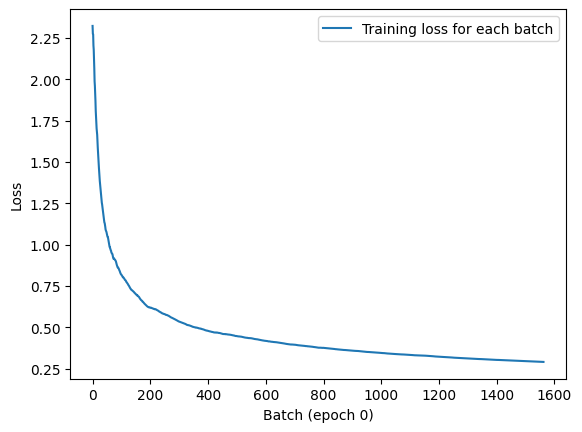

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9128 - loss: 0.2905 - val_accuracy: 0.9590 - val_loss: 0.1377
Epoch 2/3
1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9535 - loss: 0.1524

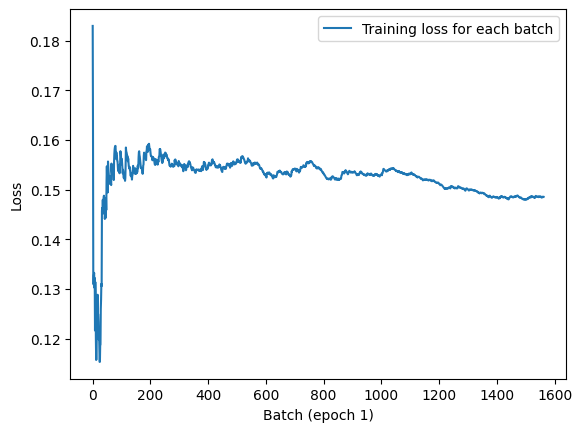

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9543 - loss: 0.1486 - val_accuracy: 0.9698 - val_loss: 0.0996
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9649 - loss: 0.1147

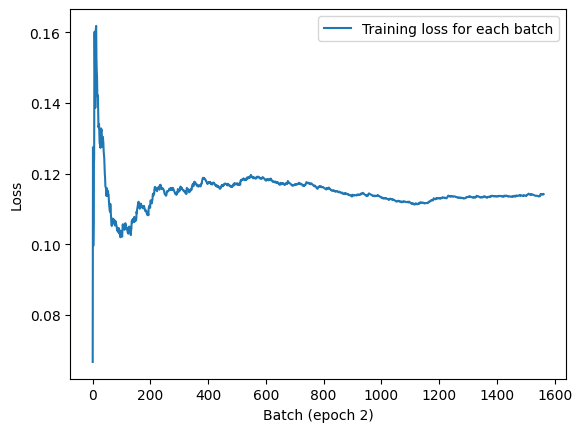

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9649 - loss: 0.1142 - val_accuracy: 0.9745 - val_loss: 0.0876


In [ ]:
# TODO: train for 3 epochs using LossHistory()
model = get_mnist_model()
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(train_images, train_labels, epochs=3,
          callbacks=[LossHistory()], validation_data=(val_images, val_labels))

---
## Exercise 6: Custom Training Loop (TensorFlow backend)

**Task:** Write a training step function using `GradientTape`, then build a full epoch loop.

In [ ]:
import tensorflow as tf

model     = get_mnist_model()
loss_fn   = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.Adam()

def train_step(inputs, targets):
    # TODO: open a GradientTape context, compute predictions + loss,
    #       compute gradients w.r.t. trainable_weights, apply them

    with tf.GradientTape() as tape:
        predictions = model(inputs, training=True)
        loss = loss_fn(targets, predictions)
    gradients = tape.gradient(loss, model.trainable_weights)
    optimizer.apply(gradients, model.trainable_weights)
    return loss

# Run one batch
loss = train_step(train_images[:32], train_labels[:32])
print(f"Loss on first batch: {loss:.4f}")

Loss on first batch: 2.3767


In [ ]:
model     = get_mnist_model()
loss_fn   = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.Adam()

train_acc_metric = keras.metrics.SparseCategoricalAccuracy()
val_acc_metric   = keras.metrics.SparseCategoricalAccuracy()

EPOCHS     = 3
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels)).shuffle(50000).batch(BATCH_SIZE)
val_dataset   = tf.data.Dataset.from_tensor_slices((val_images, val_labels)).batch(BATCH_SIZE)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    for step, (x_batch, y_batch) in enumerate(train_dataset):
        with tf.GradientTape() as tape:
            preds = model(x_batch, training=True)
            loss  = loss_fn(y_batch, preds)
        grads = tape.gradient(loss, model.trainable_weights)
        optimizer.apply(grads, model.trainable_weights)
        train_acc_metric.update_state(y_batch, preds)

        if step % 100 == 0:
            print(f"  step {step}: loss={loss:.4f}")

    print(f"  train_acc={train_acc_metric.result():.4f}")
    train_acc_metric.reset_state()

    for x_batch, y_batch in val_dataset:
        val_preds = model(x_batch, training=False)
        val_acc_metric.update_state(y_batch, val_preds)
    print(f"  val_acc={val_acc_metric.result():.4f}")
    val_acc_metric.reset_state()


Epoch 1/3
  step 0: loss=2.4624
  step 100: loss=0.2734
  step 200: loss=0.2610
  step 300: loss=0.3348
  train_acc=0.8937
  val_acc=0.9504

Epoch 2/3
  step 0: loss=0.2227
  step 100: loss=0.2276
  step 200: loss=0.2215
  step 300: loss=0.1460
  train_acc=0.9497
  val_acc=0.9620

Epoch 3/3
  step 0: loss=0.1224
  step 100: loss=0.1135
  step 200: loss=0.0933
  step 300: loss=0.1020
  train_acc=0.9606
  val_acc=0.9703


---
## Exercise 7: Overriding train_step() inside fit()

**Task:** Complete the `CustomModel` class so it uses a custom training step but still works with `fit()`.

In [ ]:
class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data

        with tf.GradientTape() as tape:
            predictions = self(inputs, training=True)
            loss = self.compute_loss(y=targets, y_pred=predictions)

        gradients = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply(gradients, self.trainable_weights)

        for metric in self.metrics:
            if metric.name == "loss":
                metric.update_state(loss)
            else:
                metric.update_state(targets, predictions)

        return {m.name: m.result() for m in self.metrics}

In [ ]:
# TODO: build the CustomModel and train it for 3 epochs
def get_custom_model():
    inputs   = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs  = layers.Dense(10, activation="softmax")(features)
    model    = CustomModel(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = get_custom_model()
model.fit(train_images, train_labels, epochs=3,
          validation_data=(val_images, val_labels))

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9148 - loss: 0.2892 - val_accuracy: 0.9624 - val_loss: 0.1331
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9547 - loss: 0.1475 - val_accuracy: 0.9672 - val_loss: 0.1045
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9638 - loss: 0.1158 - val_accuracy: 0.9734 - val_loss: 0.0915


---
##  Well done!

Once you have completed all the exercises above, compare your answers with the **demo notebook** (`ch07_demo.ipynb`) to check your solutions.